# Overhead Press — Training

Two-stage training: MD-SSL self-supervised pretraining on 5,089 unlabeled clips, then 2-seed
supervised fine-tuning. All curves regenerate from the frozen `results.pkl` (no GPU). Covers SSL
convergence and representation health, the linear-probe signal used for backbone selection, and
the fine-tune overfit control.

## Setup — load the frozen results

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_CANDS = [Path("backend/data/benchmark/ohp/results.pkl"),
          Path("../../backend/data/benchmark/ohp/results.pkl")]
_PKL = next((p for p in _CANDS if p.exists()), None)
assert _PKL is not None, "results.pkl not found"
R = pickle.load(open(_PKL, "rb"))
print("Loaded:", _PKL)
print("SSL epochs:", len(R["ssl_metrics_history"]), "| probes:", len(R["ssl_linear_probe_history"]),
      "| fine-tune seeds:", list(R["finetune_seeds"]))

Loaded: ..\..\.planning\phases\06-overhead-press\figures\results.pkl
SSL epochs: 60 | probes: 12 | fine-tune seeds: [42, 1337]


## 1. MD-SSL pretrain — loss + representation health

The SSL triplet loss falls monotonically while `effective_rank` stays well above the collapse
floor (~3): the strong augmentations prevent dimensional collapse, so the backbone learns a
usable motion representation.

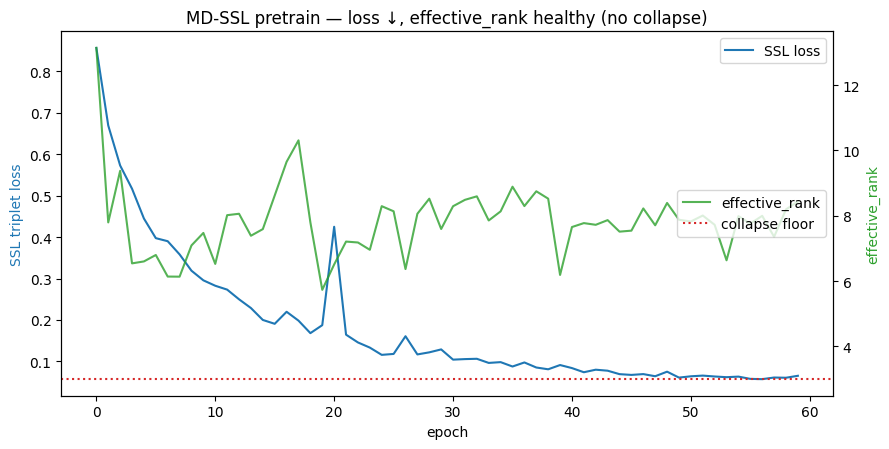

In [2]:
mh = R["ssl_metrics_history"]
ep = [m["epoch"] for m in mh]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(ep, [m["ssl_loss_mean"] for m in mh], "C0-", label="SSL loss")
ax.set_xlabel("epoch"); ax.set_ylabel("SSL triplet loss", color="C0")
ax2 = ax.twinx()
ax2.plot(ep, [m["effective_rank"] for m in mh], "C2-", alpha=0.8, label="effective_rank")
ax2.axhline(3, color="C3", ls=":", label="collapse floor")
ax2.set_ylabel("effective_rank", color="C2")
ax.set_title("MD-SSL pretrain — loss ↓, effective_rank healthy (no collapse)")
ax.legend(loc="upper right"); ax2.legend(loc="center right"); fig.tight_layout(); plt.show()

## 2. Linear-probe convergence (backbone selection)

Every 5 epochs the frozen backbone is probed with a linear head on labeled OHP. The
macro-F1 rises then plateaus; the **peak epoch is saved as `backbone.pt`** (the fork point
for fine-tuning). The later decline is SSL over-training past the useful point — discarded.

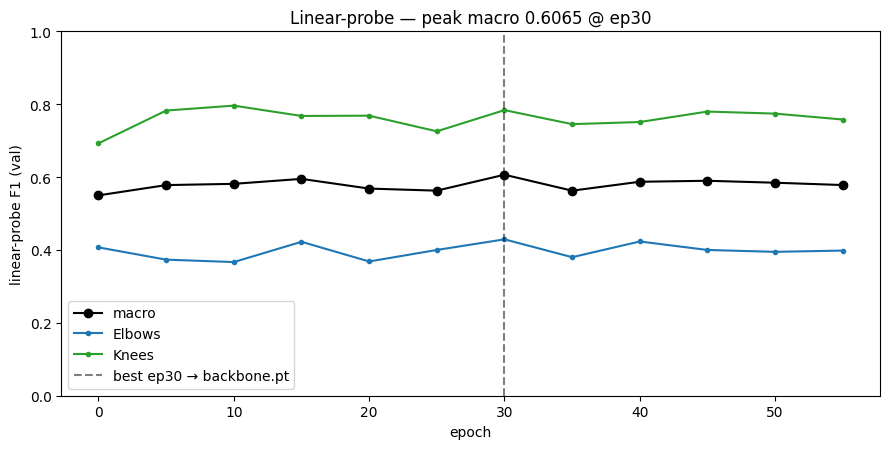

In [3]:
lp = R["ssl_linear_probe_history"]
lep = [m["epoch"] for m in lp]; lmac = [m["linear_probe_f1_macro"] for m in lp]
best = int(np.argmax(lmac))
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(lep, lmac, "k-o", label="macro")
ax.plot(lep, [m["linear_probe_f1_kie"] for m in lp], "C0-o", ms=3, label="Elbows")
ax.plot(lep, [m["linear_probe_f1_kfe"] for m in lp], "C2-o", ms=3, label="Knees")
ax.axvline(lep[best], color="k", ls="--", alpha=0.5, label=f"best ep{lep[best]} → backbone.pt")
ax.set_xlabel("epoch"); ax.set_ylabel("linear-probe F1 (val)"); ax.set_ylim(0, 1)
ax.set_title(f"Linear-probe — peak macro {lmac[best]:.4f} @ ep{lep[best]}"); ax.legend()
fig.tight_layout(); plt.show()

## 3. Fine-tune — overfit control per seed

Each seed fine-tunes from the shared backbone. The `val/train` loss ratio climbs after the
best epoch (overfitting onset); the 8-epoch early-stop selects the **pre-overfit** epoch as
`best.pt`. So the delivered models are from before overfitting set in.

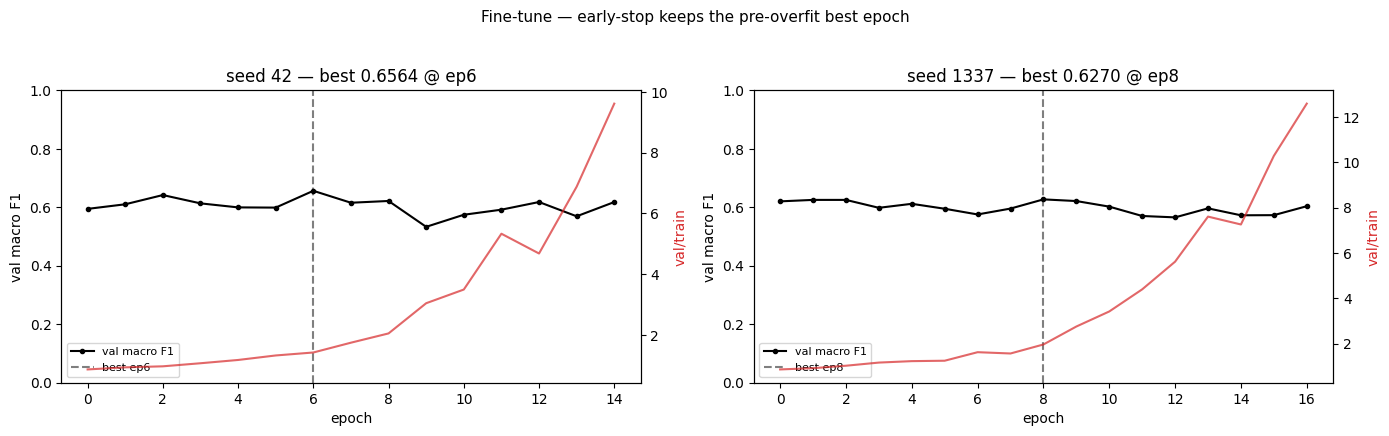

In [4]:
seeds = sorted(R["finetune_seeds"])
fig, axes = plt.subplots(1, len(seeds), figsize=(7 * len(seeds), 4.4), squeeze=False)
for ax, s in zip(axes[0], seeds):
    fh = R["finetune_seeds"][s]
    e = [m["epoch"] for m in fh]; ratio = [m["val_train_loss_ratio"] for m in fh]
    macro = [m["val_macro_f1"] for m in fh]; b = int(np.argmax(macro))
    ax.plot(e, macro, "k-o", ms=3, label="val macro F1"); ax.set_ylim(0, 1)
    ax.axvline(e[b], color="k", ls="--", alpha=0.5, label=f"best ep{e[b]}")
    a2 = ax.twinx(); a2.plot(e, ratio, "C3-", alpha=0.7, label="val/train ratio")
    a2.set_ylabel("val/train", color="C3")
    ax.set_xlabel("epoch"); ax.set_ylabel("val macro F1")
    ax.set_title(f"seed {s} — best {macro[b]:.4f} @ ep{e[b]}"); ax.legend(loc="lower left", fontsize=8)
fig.suptitle("Fine-tune — early-stop keeps the pre-overfit best epoch", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

## 4. The SSL lift (baseline → MD-SSL)

In [5]:
print(f"supervised baseline macro : {R['baseline_control']['macro']:.4f}")
print(f"MD-SSL ensemble macro     : {R['test_f1']['macro']:.4f}")
print(f"SSL lift                  : {R['ssl_lift']:+.4f}")

supervised baseline macro : 0.6118
MD-SSL ensemble macro     : 0.6622
SSL lift                  : +0.0504
